# Refining an adaptive Morse graph with fixed-subdivision reachability

A Conley-Morse graph carries three kinds of information: the Morse sets, their
Conley indices, and the reachability relation between them.  This notebook
questions only the third.

The Morse sets are recurrent components of a combinatorial multivalued map, but
the edges are accumulated across the adaptive subdivision hierarchy: when a
coarse Morse set is refined, the relations recorded at the coarse level pass to
its descendants as a cross product.  That is sound as an outer approximation, but
it can record an edge $M_i \to M_j$ that no path in the finer map realises.

`CMGDB.ComputeMorseSetReachability` detects exactly that.  For a chosen depth $s$
it exhausts the forward closure of each Morse set on the *conceptual* uniform
grid at depth $s$ — never materialising a complete `TreeGrid` or `MapGraph` —
and decides every ordered pair `REACHABLE`, `NOT_REACHABLE`, or `INCOMPLETE`.

Three notions of reachability appear below and are not interchangeable: the
**adaptive** relation stored in the `MorseGraph`; the **fixed combinatorial**
relation in $\mathcal{F}_s(x) = \mathrm{cover}_s(f(\mathrm{geo}_s(x)))$, which is
what the verifier decides; and reachability of the **true continuous dynamics**,
which nothing here resolves.

The map is the 2-D Leslie model used throughout the CMGDB examples,

$$
f(x_0, x_1) =
\begin{pmatrix}
(\theta_0 x_0 + \theta_1 x_1)\, e^{-0.1 (x_0 + x_1)} \\
0.7\, x_0
\end{pmatrix},
\qquad
\theta_0 = 19.6, \quad \theta_1 = 23.68 ,
$$

at parameters where the adaptive relation is a chain with one unrealised edge.
This cell is self-contained so the notebook runs independently of the others.


## Setup

The verifier is a fork-specific addition, so we check for it before doing any
work; this notebook must run against a CMGDB built from the current working tree.
`SUBDIV_INIT` is the parameter that produces the phenomenon — a control run later
shows that raising it alone removes the edge.


In [1]:
import hashlib
import math
import shutil
import sys
import time
from decimal import Decimal, getcontext

import matplotlib.pyplot as plt
import graphviz

import CMGDB

REQUIRED_API = [
    "ComputeMorseSetReachability",
    "ComputeMorseSetReachabilityStudy",
    "MorseSetReachabilityStatus",
    "MorseSetRelationDiagnostic",
]

missing = [name for name in REQUIRED_API if not hasattr(CMGDB, name)]
if missing:
    raise RuntimeError(
        "This notebook requires the fixed-subdivision Morse-set reachability "
        f"API, missing from the installed CMGDB: {', '.join(missing)}. "
        "Build CMGDB from the current working tree "
        "(python setup.py build_ext --inplace) and restart the kernel."
    )

# The Morse-graph figures render through graphviz, which shells out to `dot`.
if shutil.which("dot") is None:
    raise RuntimeError(
        "graphviz's `dot` executable is not on PATH; the Morse-graph figures "
        "cannot render.  Install graphviz (e.g. `brew install graphviz`)."
    )

STATUS = CMGDB.MorseSetReachabilityStatus
DIAGNOSTIC = CMGDB.MorseSetRelationDiagnostic
STOP_REASON = CMGDB.MorseSetReachabilityStopReason

print("Fixed-subdivision Morse-set reachability API available.")


Fixed-subdivision Morse-set reachability API available.


In [2]:
THETA_0  = 19.6
THETA_1  = 23.68
DECAY    = 0.1
SURVIVAL = 0.7

LOWER_BOUNDS = [-0.001, -0.001]
UPPER_BOUNDS = [ 90.0,   70.0]

SUBDIV_INIT  = 8
SUBDIV_MIN   = 16
SUBDIV_MAX   = 20
SUBDIV_LIMIT = 10_000

PHASE_SUBDIVISIONS = list(range(SUBDIV_MIN, SUBDIV_MAX + 1))
BATCH_SIZE = 4096

ENCLOSURE_VERSION = "corner+edge-critical, error-bounded, v2"
MAP_FINGERPRINT = "leslie-2d-" + hashlib.sha256(
    repr((THETA_0, THETA_1, DECAY, SURVIVAL, ENCLOSURE_VERSION)).encode()
).hexdigest()[:16]

print(f"map fingerprint: {MAP_FINGERPRINT}")


map fingerprint: leslie-2d-03a1c24172f51ba9


## A rigorous rectangle enclosure

The verifier is only as sound as its box map, and four-corner evaluation is
**not** sufficient here.  With $g(x, y) = (a x + b y)e^{-0.1(x+y)}$,

$$
\partial_x g = \bigl(a - 0.1(ax+by)\bigr) e^{-0.1(x+y)},
\qquad
\partial_y g = \bigl(b - 0.1(ax+by)\bigr) e^{-0.1(x+y)} ,
$$

so $\partial_x g$ vanishes exactly on $ax + by = 10a$ and $\partial_y g$ on
$ax + by = 10b$.  These lines are disjoint when $a \neq b$, so $g$ has no
interior stationary point and its extrema lie on the boundary — where the only
stationary points are $x^{*} = 10 - (b/a)y$ on horizontal edges and
$y^{*} = 10 - (a/b)x$ on vertical ones.  Corners plus those points give the exact
range.  ($g$ is concave along each edge, so they are maxima; the minimum is
always at a corner.)  The second component $0.7x$ is monotone, hence exact.

Exact arithmetic is not enough.  With $t = -0.1(x+y)$ the computed $\hat{t}$
carries relative error $2u$, and $e^{\hat{t}} \approx e^{t}(1 + t\delta)$
amplifies it by $|t| \le 16$ on this domain — a relative error near $10^{-15}$,
tens of ulps, where `math.nextafter` supplies one.  Each candidate value is
therefore widened by a derived error bound before the extremes are taken.


In [3]:
UNIT_ROUNDOFF = sys.float_info.epsilon / 2.0   # u = 2^-53
ERROR_SAFETY = 4.0                             # slack over the derived bound


def leslie_first_component(x, y):
    """First Leslie component g(x, y) = (a x + b y) exp(-0.1 (x + y))."""
    return (THETA_0 * x + THETA_1 * y) * math.exp(-DECAY * (x + y))


def leslie_first_component_bounded(x, y):
    """g(x, y) in floating point, with a certified absolute error bound."""
    scale = THETA_0 * x + THETA_1 * y
    argument = -DECAY * (x + y)
    factor = math.exp(argument)
    value = scale * factor

    error_scale = 2.0 * UNIT_ROUNDOFF * (abs(THETA_0 * x) + abs(THETA_1 * y))
    relative_factor = (2.0 * abs(argument) + 1.0) * UNIT_ROUNDOFF
    bound = ERROR_SAFETY * (
        error_scale * factor
        + abs(scale) * factor * relative_factor
        + abs(value) * UNIT_ROUNDOFF
    )
    return value, bound


def leslie_candidates(rect):
    """Corners plus the edge-interior critical points of g inside rect."""
    x_min, y_min, x_max, y_max = rect
    candidates = [(x, y) for x in (x_min, x_max) for y in (y_min, y_max)]
    for y in (y_min, y_max):
        x_star = 10.0 - (THETA_1 / THETA_0) * y
        if x_min <= x_star <= x_max:
            candidates.append((x_star, y))
    for x in (x_min, x_max):
        y_star = 10.0 - (THETA_0 / THETA_1) * x
        if y_min <= y_star <= y_max:
            candidates.append((x, y_star))
    return candidates


def leslie_box_map(rect):
    """Rigorous outer enclosure of the Leslie map on a rectangle.

    rect is [x_min, y_min, x_max, y_max]; the result is an enclosure
    [g_min, h_min, g_max, h_max] of the image.  Each candidate value is
    widened by its certified floating-point error bound before the
    extremes are taken, then rounded outward one further ulp.
    """
    x_min, y_min, x_max, y_max = rect

    lows, highs = [], []
    for x, y in leslie_candidates(rect):
        value, bound = leslie_first_component_bounded(x, y)
        lows.append(value - bound)
        highs.append(value + bound)

    return [
        math.nextafter(min(lows), -math.inf),
        math.nextafter(SURVIVAL * x_min, -math.inf),
        math.nextafter(max(highs), math.inf),
        math.nextafter(SURVIVAL * x_max, math.inf),
    ]


def leslie_box_map_one_ulp(rect):
    """The naive variant: exact-arithmetic extremes, one ulp of margin.

    Kept only to demonstrate below that this is not a valid enclosure.
    """
    values = [leslie_first_component(x, y) for x, y in leslie_candidates(rect)]
    x_min, x_max = rect[0], rect[2]
    return [
        math.nextafter(min(values), -math.inf),
        math.nextafter(SURVIVAL * x_min, -math.inf),
        math.nextafter(max(values), math.inf),
        math.nextafter(SURVIVAL * x_max, math.inf),
    ]


def leslie_box_map_batch(rects):
    """Pointwise-identical batch callback: the same enclosure, per rectangle."""
    return [leslie_box_map(rect) for rect in rects]


The test below must not be circular: comparing the enclosure against the same
floating-point evaluation that built it can never fail.  We evaluate the
reference with `decimal` at 60 digits instead.  Sample points are taken at the
exact corners, since interpolating to them can overshoot by one ulp.


In [4]:
SAMPLE_RECTS = [
    [-0.001, -0.001, 90.0, 70.0],   # the whole domain
    [  0.0,    0.0,  12.0,  9.0],   # straddles both critical lines
    [  5.0,    3.0,   5.7,  3.9],   # small interior box
    [ 30.0,   20.0,  45.0, 33.0],   # far side of the critical lines
    [  0.0,   60.0,   1.0, 70.0],   # thin box near the top edge
]
SAMPLES_PER_AXIS = 21
getcontext().prec = 60


def leslie_first_component_exact(x, y):
    """g(x, y) evaluated at 60 significant digits, as a Decimal."""
    big_x, big_y = Decimal(x), Decimal(y)
    scale = Decimal(THETA_0) * big_x + Decimal(THETA_1) * big_y
    return scale * (-Decimal(DECAY) * (big_x + big_y)).exp()


def sample_coordinate(low, high, index, count):
    """Sample point that is never outside [low, high] by a rounding step."""
    if index == 0:
        return low
    if index == count - 1:
        return high
    return min(max(low + (high - low) * index / (count - 1), low), high)


n_samples = 0

for rect in SAMPLE_RECTS:
    x_min, y_min, x_max, y_max = rect
    g_min, h_min, g_max, h_max = leslie_box_map(rect)
    for i in range(SAMPLES_PER_AXIS):
        for j in range(SAMPLES_PER_AXIS):
            x = sample_coordinate(x_min, x_max, i, SAMPLES_PER_AXIS)
            y = sample_coordinate(y_min, y_max, j, SAMPLES_PER_AXIS)
            exact = leslie_first_component_exact(x, y)
            n_samples += 1
            assert Decimal(g_min) <= exact <= Decimal(g_max), (
                f"enclosure misses the exact g{(x, y)} = {exact} "
                f"for rect {rect}"
            )
            assert h_min <= SURVIVAL * x <= h_max, (
                f"enclosure misses 0.7*{x} for rect {rect}"
            )

assert leslie_box_map_batch(SAMPLE_RECTS) == [
    leslie_box_map(rect) for rect in SAMPLE_RECTS
], "batch callback disagrees with the scalar callback"

print(f"Enclosure contains the 60-digit exact image at all {n_samples} "
      f"sampled points across {len(SAMPLE_RECTS)} rectangles.")
print("Batch callback is pointwise identical to the scalar callback.")

# The widening must be negligible against the grid, or it would blunt the
# analysis rather than merely making it sound.
widest = max(
    leslie_first_component_bounded(x, y)[1]
    for rect in SAMPLE_RECTS
    for x, y in leslie_candidates(rect)
)
cell_width = (UPPER_BOUNDS[0] - LOWER_BOUNDS[0]) / 2 ** (SUBDIV_MAX // 2)
print(f"Largest error widening {widest:.3e} is {widest / cell_width:.1e} of a "
      f"depth-{SUBDIV_MAX} cell width ({cell_width:.4f}).")


Enclosure contains the 60-digit exact image at all 2205 sampled points across 5 rectangles.
Batch callback is pointwise identical to the scalar callback.
Largest error widening 2.321e-13 is 2.6e-12 of a depth-20 cell width (0.0879).


That is necessary but not sufficient, and it does not show the one-ulp margin was
inadequate.  This degenerate rectangle — a single point, where $x + y \approx 128$
maximises the amplification — does.


In [5]:
PROBE_X, PROBE_Y = 62.48817722746601, 65.85392009332787
probe_rect = [PROBE_X, PROBE_Y, PROBE_X, PROBE_Y]

exact_value = leslie_first_component_exact(PROBE_X, PROBE_Y)
naive_low, _, naive_high, _ = leslie_box_map_one_ulp(probe_rect)
safe_low, _, safe_high, _ = leslie_box_map(probe_rect)

naive_contains = Decimal(naive_low) <= exact_value <= Decimal(naive_high)
safe_contains = Decimal(safe_low) <= exact_value <= Decimal(safe_high)

assert not naive_contains, "the one-ulp variant unexpectedly contains the image"
assert safe_contains, "the error-bounded enclosure misses the image"

deficit = Decimal(naive_low) - exact_value
print(f"f({PROBE_X}, {PROBE_Y})")
print(f"  exact first component : {exact_value:.24f}")
print(f"  one-ulp enclosure     : [{naive_low!r}, {naive_high!r}]")
print(f"     contains the image : {naive_contains}  "
      f"(low bound too high by {float(deficit):.3e} = "
      f"{float(deficit / Decimal(math.ulp(float(exact_value)))):.1f} ulp)")
print(f"  error-bounded enclosure: [{safe_low!r}, {safe_high!r}]")
print(f"     contains the image : {safe_contains}")


f(62.48817722746601, 65.85392009332787)
  exact first component : 0.007428006291056923111946
  one-ulp enclosure     : [0.007428006291056938, 0.00742800629105694]
     contains the image : False  (low bound too high by 1.501e-17 = 17.3 ulp)
  error-bounded enclosure: [0.00742800629105684, 0.007428006291057038]
     contains the image : True


One consequence, needed for the closing interpretation: applied to the whole
domain the enclosure is exact, and the resulting range is not contained in the
domain.  The truncated phase space is **not forward invariant**, so `cover` clips
escaping images.


In [6]:
domain_image = leslie_box_map(LOWER_BOUNDS + UPPER_BOUNDS)
g_low, h_low, g_high, h_high = domain_image

print(f"Exact image range over the domain: "
      f"[{g_low:.4f}, {g_high:.4f}] x [{h_low:.4f}, {h_high:.4f}]")
print(f"Phase space:                       "
      f"[{LOWER_BOUNDS[0]}, {UPPER_BOUNDS[0]}] x "
      f"[{LOWER_BOUNDS[1]}, {UPPER_BOUNDS[1]}]")

forward_invariant = (
    g_low >= LOWER_BOUNDS[0] and g_high <= UPPER_BOUNDS[0]
    and h_low >= LOWER_BOUNDS[1] and h_high <= UPPER_BOUNDS[1]
)
print(f"Domain forward invariant: {forward_invariant}")
print(f"Corner image f({LOWER_BOUNDS[0]}, {LOWER_BOUNDS[1]}) has first "
      f"component {leslie_first_component(*LOWER_BOUNDS):.4f}, "
      f"below the lower bound {LOWER_BOUNDS[0]}.")


Exact image range over the domain: [-0.0433, 87.1154] x [-0.0007, 63.0000]
Phase space:                       [-0.001, 90.0] x [-0.001, 70.0]
Domain forward invariant: False
Corner image f(-0.001, -0.001) has first component -0.0433, below the lower bound -0.001.


## The adaptive Conley-Morse graph

`ComputeConleyMorseGraph` also computes Conley indices, which label the Morse
sets independently of their integer numbering.  The bounding envelopes below are
summaries only: the Morse sets are unions of grid cells and are far from
rectangular.


In [7]:
model = CMGDB.Model(
    SUBDIV_MIN,
    SUBDIV_MAX,
    SUBDIV_INIT,
    SUBDIV_LIMIT,
    LOWER_BOUNDS,
    UPPER_BOUNDS,
    leslie_box_map,
)
model.set_batch_map(leslie_box_map_batch)

start = time.monotonic()
morse_graph, _ = CMGDB.ComputeConleyMorseGraph(model)
adaptive_seconds = time.monotonic() - start

num_vertices = morse_graph.num_vertices()
adaptive_unreduced = set(map(tuple, morse_graph.edges_unreduced()))
adaptive_reduced = set(map(tuple, morse_graph.edges()))

assert num_vertices == 4, (
    f"expected 4 Morse sets for this Leslie fixture; found {num_vertices}"
)
assert adaptive_unreduced == {(1, 0), (2, 0), (2, 1), (3, 0), (3, 1), (3, 2)}, (
    f"unexpected adaptive relation: {sorted(adaptive_unreduced)}"
)
assert adaptive_reduced == {(1, 0), (2, 1), (3, 2)}, (
    f"unexpected adaptive Hasse diagram: {sorted(adaptive_reduced)}"
)

print(f"Adaptive computation: {adaptive_seconds:.1f} s, "
      f"{num_vertices} Morse sets.")
print(f"Unreduced relation: {sorted(adaptive_unreduced)}")
print(f"Hasse diagram:      {sorted(adaptive_reduced)}")


Adaptive computation: 0.1 s, 4 Morse sets.


Unreduced relation: [(1, 0), (2, 0), (2, 1), (3, 0), (3, 1), (3, 2)]
Hasse diagram:      [(1, 0), (2, 1), (3, 2)]


In [8]:
print(f"{'node':>4}  {'Conley index':<18}  {'cells':>6}  "
      f"{'x range':<20}  {'y range':<20}")
print("-" * 76)
for v in range(num_vertices):
    boxes = morse_graph.morse_set_boxes(v)
    index = "(" + ", ".join(morse_graph.annotations(v)) + ")"
    x_range = f"[{min(b[0] for b in boxes):.3f}, {max(b[2] for b in boxes):.3f}]"
    y_range = f"[{min(b[1] for b in boxes):.3f}, {max(b[3] for b in boxes):.3f}]"
    print(f"{v:>4}  {index:<18}  {len(morse_graph.morse_set(v)):>6}  "
          f"{x_range:<20}  {y_range:<20}")

EXPECTED_ANNOTATIONS = {
    0: ("x^3-1", "0", "0"),
    1: ("x-1", "0", "0"),
    2: ("0", "x^3-1", "0"),
    3: ("0", "0", "0"),
}
EXPECTED_CELL_COUNTS = {0: 158, 1: 5570, 2: 89, 3: 1}

for v, annotation in EXPECTED_ANNOTATIONS.items():
    assert tuple(morse_graph.annotations(v)) == annotation, (
        f"node {v} has Conley index {morse_graph.annotations(v)}, "
        f"expected {annotation}"
    )
    assert len(morse_graph.morse_set(v)) == EXPECTED_CELL_COUNTS[v], (
        f"node {v} has {len(morse_graph.morse_set(v))} cells, "
        f"expected {EXPECTED_CELL_COUNTS[v]}"
    )


node  Conley index         cells  x range               y range             
----------------------------------------------------------------------------
   0  (x^3-1, 0, 0)          158  [0.351, 73.828]       [-0.001, 51.953]    
   1  (x-1, 0, 0)           5570  [3.866, 43.242]       [2.460, 30.351]     
   2  (0, x^3-1, 0)           89  [1.405, 54.492]       [0.819, 38.007]     
   3  (0, 0, 0)                1  [-0.001, 0.351]       [-0.001, 0.272]     


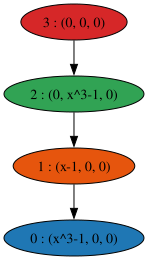

In [9]:
# The adaptive Morse graph as CMGDB draws it (edges point from higher to lower).
CMGDB.PlotMorseGraph(morse_graph)


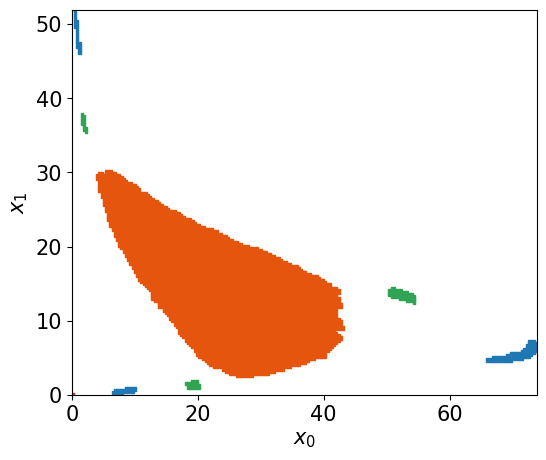

In [10]:
# M3 is the single cell at the origin; M1 is the large recurrent region.
CMGDB.PlotMorseSets(morse_graph, fig_w=6, fig_h=5,
                    xlabel="$x_0$", ylabel="$x_1$")
plt.show()


## The candidate edge

We select the pair by Conley index — source $(x-1, 0, 0)$, target
$(x^3-1, 0, 0)$ — so the *selection* does not depend on node numbering.  The
fixture assertions do, deliberately, so that a change in numbering fails loudly.

An adaptive edge does not assert a single-step map adjacency; it asserts
reachability recorded during the computation, which for sets separated in the
hierarchy may have been inherited rather than realised.


In [11]:
def vertex_by_conley_index(mg, annotation):
    """Return the unique Morse node carrying the given Conley index."""
    matches = [
        v for v in range(mg.num_vertices())
        if tuple(mg.annotations(v)) == annotation
    ]
    if len(matches) != 1:
        raise LookupError(
            f"expected exactly one node with Conley index {annotation}, "
            f"found {matches}"
        )
    return matches[0]


SOURCE = vertex_by_conley_index(morse_graph, ("x-1", "0", "0"))
TARGET = vertex_by_conley_index(morse_graph, ("x^3-1", "0", "0"))
CANDIDATE = (SOURCE, TARGET)

assert CANDIDATE == (1, 0), f"candidate pair is {CANDIDATE}, expected (1, 0)"
assert CANDIDATE in adaptive_unreduced, (
    f"{CANDIDATE} is not an adaptive edge: {sorted(adaptive_unreduced)}"
)

print(f"Candidate edge: M{SOURCE} -> M{TARGET}  {CANDIDATE}")


Candidate edge: M1 -> M0  (1, 0)


## Fixed-subdivision verification

`phase_subdiv=s` is the **total** binary `TreeGrid` depth, not a per-coordinate
level: one coordinate is split per level, so a complete grid at depth $s$ holds
$2^{s}$ cells.  The verifier builds none of it — it enumerates each Morse set's
descendants as integer ranges and expands only the cells its closure reaches.
Both budgets are left unset so every closure runs to exhaustion; only an
exhausted closure can certify `NOT_REACHABLE`.

The lowest depth is not arbitrary.  `SUBDIV_LIMIT` halts refinement before
`SUBDIV_MAX`, leaving every Morse-set leaf at depth 16 — so $s = 16$ is the grid
the adaptive computation itself finished on, and the sharpest test rather than
the coarsest.


In [12]:
leaf_depths = [
    node["max_adaptive_leaf_depth"]
    for node in CMGDB.ComputeMorseSetReachability(
        model, morse_graph, phase_subdiv=SUBDIV_MIN
    ).provenance()["morse_graph"]["nodes"]
]

assert set(leaf_depths) == {SUBDIV_MIN}, (
    f"adaptive Morse-set leaf depths are {leaf_depths}, expected all "
    f"{SUBDIV_MIN}"
)

print(f"Adaptive Morse-set leaf depths: {leaf_depths}")
print(f"SUBDIV_LIMIT={SUBDIV_LIMIT} halted refinement at depth {SUBDIV_MIN}, "
      f"below SUBDIV_MAX={SUBDIV_MAX};")
print(f"so s={SUBDIV_MIN} is the adaptive computation's own final grid.")


Adaptive Morse-set leaf depths: [16, 16, 16, 16]
SUBDIV_LIMIT=10000 halted refinement at depth 16, below SUBDIV_MAX=20;
so s=16 is the adaptive computation's own final grid.


In [13]:
results = {}
timings = {}

for subdiv in PHASE_SUBDIVISIONS:
    start = time.monotonic()
    results[subdiv] = CMGDB.ComputeMorseSetReachability(
        model,
        morse_graph,
        phase_subdiv=subdiv,
        max_visited_grid_elements=None,
        max_adjacencies_examined=None,
        batch_size=BATCH_SIZE,
        map_fingerprint=MAP_FINGERPRINT,
    )
    timings[subdiv] = time.monotonic() - start

print(f"{'subdiv':>6}  {'M1 -> M0':<14}  {'complete':>8}  "
      f"{'diagnostic':<20}  {'src done':>8}  {'src stop':<8}  absent edges")
print("-" * 100)
for subdiv, result in results.items():
    print(f"{subdiv:>6}  {result.status(*CANDIDATE).name:<14}  "
          f"{str(result.complete()):>8}  {result.diagnostics().name:<20}  "
          f"{str(result.frontier_exhausted(SOURCE)):>8}  "
          f"{result.stop_reason(SOURCE).name:<8}  "
          f"{sorted(map(tuple, result.absent_adaptive_edges()))}")


subdiv  M1 -> M0        complete  diagnostic            src done  src stop  absent edges
----------------------------------------------------------------------------------------------------
    16  NOT_REACHABLE       True  VALID_PARTIAL_ORDER       True  NONE      [(1, 0)]
    17  NOT_REACHABLE       True  VALID_PARTIAL_ORDER       True  NONE      [(1, 0)]
    18  NOT_REACHABLE       True  VALID_PARTIAL_ORDER       True  NONE      [(1, 0)]
    19  NOT_REACHABLE       True  VALID_PARTIAL_ORDER       True  NONE      [(1, 0)]
    20  NOT_REACHABLE       True  VALID_PARTIAL_ORDER       True  NONE      [(1, 0)]


Every row is complete, and every row reports `M1 -> M0` as `NOT_REACHABLE` with
`(1, 0)` the sole absent edge.  Counts below total all four sources; the
wall-clock column is indicative and is not asserted anywhere.


In [14]:
def totals(result, accessor):
    return sum(accessor(result, v) for v in range(num_vertices))


print(f"{'subdiv':>6}  {'visited':>9}  {'expanded':>9}  {'adjacencies':>12}  "
      f"{'map evals':>10}  {'batches':>8}  {'seconds':>8}")
print("-" * 74)
for subdiv, result in results.items():
    print(f"{subdiv:>6}  "
          f"{totals(result, lambda r, v: r.visited_grid_elements(v)):>9}  "
          f"{totals(result, lambda r, v: r.grid_elements_expanded(v)):>9}  "
          f"{totals(result, lambda r, v: r.adjacencies_examined(v)):>12}  "
          f"{totals(result, lambda r, v: r.map_evaluations_attempted(v)):>10}  "
          f"{totals(result, lambda r, v: r.map_batches_attempted(v)):>8}  "
          f"{timings[subdiv]:>8.2f}")


subdiv    visited   expanded   adjacencies   map evals   batches   seconds
--------------------------------------------------------------------------
    16      21714      21714        137348       21714        62      0.05
    17      40297      40297        253778       40297        80      0.10
    18      75068      75068        482255       75068       109      0.18
    19     141111     141111        901806      141111       150      0.36
    20     267293     267293       1737555      267293       209      0.67


In [15]:
finest = results[SUBDIV_MAX]
finest_sources = finest.provenance()["sources"]

print(f"Per-source detail at phase_subdiv={SUBDIV_MAX}")
print(f"{'node':>4}  {'Conley index':<18}  {'seeds':>7}  {'visited':>8}  "
      f"{'expanded':>8}  {'adjacencies':>12}  {'stop':<6}  reaches")
print("-" * 96)
for v in range(num_vertices):
    index = "(" + ", ".join(morse_graph.annotations(v)) + ")"
    print(f"{v:>4}  {index:<18}  {finest_sources[v]['fixed_seed_count']:>7}  "
          f"{finest.visited_grid_elements(v):>8}  "
          f"{finest.grid_elements_expanded(v):>8}  "
          f"{finest.adjacencies_examined(v):>12}  "
          f"{finest.stop_reason(v).name:<6}  "
          f"{sorted(finest.adjacencies_unreduced(v))}")


Per-source detail at phase_subdiv=20
node  Conley index          seeds   visited  expanded   adjacencies  stop    reaches
------------------------------------------------------------------------------------------------
   0  (x^3-1, 0, 0)          2528      2528      2528          9264  NONE    []
   1  (x-1, 0, 0)           89120     89120     89120        588547  NONE    []
   2  (0, x^3-1, 0)          1424     75603     75603        497308  NONE    [0, 1]
   3  (0, 0, 0)                16    100042    100042        642436  NONE    [0, 1, 2]


The `visited` column explains the verdict: for $M_0$ and $M_1$ it equals the seed
count exactly, so both are **forward invariant** in the fixed combinatorial
system.  A forward-invariant source reaches nothing outside itself, which is why
the answer is decisive rather than marginal.


## Correctness assertions

Checked at every tested depth.  No pair may be `INCOMPLETE`: a cut-short closure
can never justify removing an edge.  The verifier must also leave the input
`MorseGraph` untouched.


In [16]:
VERIFIED_UNREDUCED = {(2, 0), (2, 1), (3, 0), (3, 1), (3, 2)}
VERIFIED_REDUCED = {(2, 0), (2, 1), (3, 2)}
ZERO_INSTRUMENTATION = {
    "complete_treegrid_materializations": 0,
    "mapgraph_constructions": 0,
    "complete_vertex_array_bytes": 0,
    "complete_edge_array_bytes": 0,
}

for subdiv, result in results.items():
    assert result.complete(), f"subdivision {subdiv} did not complete"
    assert result.diagnostics() == DIAGNOSTIC.VALID_PARTIAL_ORDER, (
        f"subdivision {subdiv} reports {result.diagnostics().name}"
    )

    for v in range(num_vertices):
        assert result.frontier_exhausted(v), (
            f"subdivision {subdiv}: closure of M{v} not exhausted"
        )
        assert result.stop_reason(v) == STOP_REASON.NONE, (
            f"subdivision {subdiv}: M{v} stopped with "
            f"{result.stop_reason(v).name}"
        )
        assert result.error(v) is None, (
            f"subdivision {subdiv}: M{v} reported {result.error(v)}"
        )
        for w in range(num_vertices):
            assert result.status(v, w) != STATUS.INCOMPLETE, (
                f"subdivision {subdiv}: pair ({v}, {w}) is INCOMPLETE"
            )

    assert result.status(*CANDIDATE) == STATUS.NOT_REACHABLE, (
        f"subdivision {subdiv}: candidate {CANDIDATE} is "
        f"{result.status(*CANDIDATE).name}"
    )
    absent = set(map(tuple, result.absent_adaptive_edges()))
    assert absent == {CANDIDATE}, (
        f"subdivision {subdiv}: absent adaptive edges are {sorted(absent)}"
    )

    strict = {
        (v, w)
        for v in range(num_vertices)
        for w in range(num_vertices)
        if v != w and result.status(v, w) == STATUS.REACHABLE
    }
    assert strict == VERIFIED_UNREDUCED, (
        f"subdivision {subdiv}: verified relation is {sorted(strict)}"
    )

    reduced = {
        (v, w) for v in range(num_vertices) for w in result.adjacencies(v)
    }
    assert reduced == VERIFIED_REDUCED, (
        f"subdivision {subdiv}: verified reduction is {sorted(reduced)}"
    )

    provenance = result.provenance()

    # M0 and M1 are forward invariant: their closures never leave them.
    for v in (SOURCE, TARGET):
        seeds = provenance["sources"][v]["fixed_seed_count"]
        assert result.visited_grid_elements(v) == seeds, (
            f"subdivision {subdiv}: M{v} closure visited "
            f"{result.visited_grid_elements(v)} cells from {seeds} seeds, "
            "so it is not forward invariant"
        )

    assert provenance["verification"]["phase_subdiv"] == subdiv, (
        f"provenance records subdivision "
        f"{provenance['verification']['phase_subdiv']}, expected {subdiv}"
    )
    # Plumbing check only: this echoes the argument passed in, so it confirms
    # the fingerprint reaches provenance intact, not that it identifies the map.
    assert provenance["model"]["map_fingerprint"] == MAP_FINGERPRINT, (
        f"provenance records fingerprint "
        f"{provenance['model']['map_fingerprint']!r}"
    )
    assert provenance["verification"]["instrumentation"] == ZERO_INSTRUMENTATION, (
        f"subdivision {subdiv} materialised structures it must not: "
        f"{provenance['verification']['instrumentation']}"
    )

print(f"All assertions hold at subdivisions "
      f"{PHASE_SUBDIVISIONS[0]}-{PHASE_SUBDIVISIONS[-1]}.")


All assertions hold at subdivisions 16-20.


In [17]:
def morse_graph_signature(mg):
    """Content signature of a MorseGraph: geometry, indices, relation."""
    return (
        tuple(
            tuple(sorted(map(tuple, mg.morse_set_boxes(v))))
            for v in range(mg.num_vertices())
        ),
        tuple(tuple(mg.annotations(v)) for v in range(mg.num_vertices())),
        tuple(sorted(mg.edges_unreduced())),
    )


signature_after = morse_graph_signature(morse_graph)

assert set(map(tuple, morse_graph.edges_unreduced())) == adaptive_unreduced, (
    "verification changed the adaptive unreduced relation"
)
assert set(map(tuple, morse_graph.edges())) == adaptive_reduced, (
    "verification changed the adaptive Hasse diagram"
)
assert signature_after == morse_graph_signature(morse_graph), (
    "MorseGraph signature is not stable"
)

print("Input MorseGraph unchanged by verification.")


Input MorseGraph unchanged by verification.


## Cross-check against a complete MapGraph

At the coarsest depth the complete object is small enough to build directly, so
the lazy answer can be checked against a brute-force closure over a full
`MapGraph`.  This is evidence, not method.  It assumes the provenance
`fixed_ranges` are half-open and that fixed-grid identifiers coincide with the
leaf ordering of a complete uniform `TreeGrid`; the final `adjacencies_examined`
comparison couples to traversal multiplicity rather than to a mathematical
invariant.


In [18]:
CROSSCHECK_SUBDIV = SUBDIV_MIN

reference_model = CMGDB.Model(
    CROSSCHECK_SUBDIV,
    LOWER_BOUNDS,
    UPPER_BOUNDS,
    leslie_box_map,
)
reference_model.set_batch_map(leslie_box_map_batch)

start = time.monotonic()
_, reference_map_graph = CMGDB.ComputeMorseGraph(reference_model)
reference_seconds = time.monotonic() - start

assert reference_map_graph.num_vertices() == 2 ** CROSSCHECK_SUBDIV, (
    f"reference grid has {reference_map_graph.num_vertices()} cells, "
    f"expected {2 ** CROSSCHECK_SUBDIV}"
)

# Fixed-subdivision cells of each Morse set, taken from the provenance ranges.
crosscheck = results[CROSSCHECK_SUBDIV]
morse_cells = [
    {
        cell
        for first, last in node["fixed_ranges"]
        for cell in range(first, last)
    }
    for node in crosscheck.provenance()["morse_graph"]["nodes"]
]

for v in range(num_vertices):
    visited = set(morse_cells[v])
    stack = list(visited)
    examined = 0
    while stack:
        current = stack.pop()
        for successor in reference_map_graph.adjacencies(current):
            examined += 1
            successor = int(successor)
            if successor not in visited:
                visited.add(successor)
                stack.append(successor)

    assert crosscheck.visited_grid_elements(v) == len(visited), (
        f"M{v}: verifier visited {crosscheck.visited_grid_elements(v)} cells, "
        f"brute force visited {len(visited)}"
    )
    assert crosscheck.adjacencies_examined(v) == examined, (
        f"M{v}: verifier examined {crosscheck.adjacencies_examined(v)} "
        f"adjacencies, brute force examined {examined}"
    )
    for w in range(num_vertices):
        expected = (STATUS.REACHABLE if (morse_cells[w] & visited)
                    else STATUS.NOT_REACHABLE)
        assert crosscheck.status(v, w) == expected, (
            f"pair ({v}, {w}): verifier says {crosscheck.status(v, w).name}, "
            f"brute force says {expected.name}"
        )

print(f"Complete MapGraph at depth {CROSSCHECK_SUBDIV}: "
      f"{reference_map_graph.num_vertices()} cells, "
      f"{reference_map_graph.num_cached_edges()} edges, "
      f"{reference_seconds:.1f} s to build.")
print("Lazy verifier agrees with the brute-force closure on every status, "
      "visited count and adjacency count.")


Complete MapGraph at depth 16: 65536 cells, 215410 edges, 0.4 s to build.
Lazy verifier agrees with the brute-force closure on every status, visited count and adjacency count.


## A control run: where the edge comes from

Both the verdict and the counts point at inheritance from a level coarser than
the grid the Morse sets ended on.  That predicts something falsifiable: start
deeper and the edge should never be recorded.  We change `SUBDIV_INIT` from 8 to
16 and nothing else.


In [19]:
control_model = CMGDB.Model(
    SUBDIV_MIN,
    SUBDIV_MAX,
    SUBDIV_MIN,        # SUBDIV_INIT raised from 8 to 16
    SUBDIV_LIMIT,
    LOWER_BOUNDS,
    UPPER_BOUNDS,
    leslie_box_map,
)
control_model.set_batch_map(leslie_box_map_batch)

start = time.monotonic()
control_graph, _ = CMGDB.ComputeConleyMorseGraph(control_model)
control_seconds = time.monotonic() - start

control_unreduced = set(map(tuple, control_graph.edges_unreduced()))
control_cells = [
    len(control_graph.morse_set(v)) for v in range(control_graph.num_vertices())
]
adaptive_cells = [
    len(morse_graph.morse_set(v)) for v in range(num_vertices)
]

# Same Morse sets, same Conley indices, one fewer edge.
assert control_graph.num_vertices() == num_vertices
assert control_cells == adaptive_cells, (
    f"control cell counts {control_cells} differ from {adaptive_cells}"
)
for v in range(num_vertices):
    assert control_graph.annotations(v) == morse_graph.annotations(v), v
assert control_unreduced == adaptive_unreduced - {CANDIDATE}, (
    f"control relation {sorted(control_unreduced)} is not the adaptive "
    f"relation minus {CANDIDATE}"
)
assert control_unreduced == VERIFIED_UNREDUCED, (
    f"control relation {sorted(control_unreduced)} differs from the verified "
    f"relation {sorted(VERIFIED_UNREDUCED)}"
)

print(f"SUBDIV_INIT={SUBDIV_MIN} control run: {control_seconds:.1f} s")
print(f"  Morse sets:  {control_cells} (identical)")
print(f"  relation:    {sorted(control_unreduced)}")
print(f"  adaptive was {sorted(adaptive_unreduced)}")
print(f"  difference:  {sorted(adaptive_unreduced - control_unreduced)}")
print("The control relation equals the verified relation exactly.")


SUBDIV_INIT=16 control run: 0.5 s
  Morse sets:  [158, 5570, 89, 1] (identical)
  relation:    [(2, 0), (2, 1), (3, 0), (3, 1), (3, 2)]
  adaptive was [(1, 0), (2, 0), (2, 1), (3, 0), (3, 1), (3, 2)]
  difference:  [(1, 0)]
The control relation equals the verified relation exactly.


The prediction holds sharply — same four Morse sets, same cell counts, same
Conley indices, no $M_1 \to M_0$, and a relation equal to the verified one.  Two
independent routes agree that the edge is an artifact of the coarse initial grid.
The verifier reaches that conclusion without recomputing the decomposition or its
Conley indices, and with an explicit certificate; the control run is the more
expensive way to learn the same thing.


## The multi-subdivision study

`ComputeMorseSetReachabilityStudy` repeats the verification at each depth
**independently** — nothing is carried between depths — and classifies each pair
`AGREE_REACHABLE`, `AGREE_NOT_REACHABLE`, `UNSTABLE` (completed results
disagree), or `UNRESOLVED` (some result was `INCOMPLETE`).


In [20]:
start = time.monotonic()
study = CMGDB.ComputeMorseSetReachabilityStudy(
    model,
    morse_graph,
    PHASE_SUBDIVISIONS,
    max_visited_grid_elements=None,
    max_adjacencies_examined=None,
    batch_size=BATCH_SIZE,
    map_fingerprint=MAP_FINGERPRINT,
)
study_seconds = time.monotonic() - start

assert study.classification(SOURCE, TARGET) == CMGDB.AGREE_NOT_REACHABLE, (
    f"candidate classified {study.classification(SOURCE, TARGET)}"
)
assert study.prunable_adaptive_edges() == [CANDIDATE], (
    f"prunable edges are {study.prunable_adaptive_edges()}"
)
assert study.unstable_pairs() == [], (
    f"unstable pairs: {study.unstable_pairs()}"
)
assert study.unresolved_pairs() == [], (
    f"unresolved pairs: {study.unresolved_pairs()}"
)

header = "  ".join(f"s={s:<13}" for s in PHASE_SUBDIVISIONS)
print(f"{'pair':<12}  {'adaptive':>8}  {'classification':<22}  {header}")
print("-" * (48 + 15 * len(PHASE_SUBDIVISIONS)))
for v in range(num_vertices):
    for w in range(num_vertices):
        if v == w:
            continue
        row = "  ".join(
            f"{study.result(s).status(v, w).name:<15}"
            for s in PHASE_SUBDIVISIONS
        )
        print(f"{f'M{v} -> M{w}':<12}  "
              f"{str((v, w) in adaptive_unreduced):>8}  "
              f"{study.classification(v, w):<22}  {row}")

print(f"\nStudy of {len(PHASE_SUBDIVISIONS)} subdivisions: "
      f"{study_seconds:.1f} s.")


pair          adaptive  classification          s=16             s=17             s=18             s=19             s=20           
---------------------------------------------------------------------------------------------------------------------------
M0 -> M1         False  AGREE_NOT_REACHABLE     NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE  
M0 -> M2         False  AGREE_NOT_REACHABLE     NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE  
M0 -> M3         False  AGREE_NOT_REACHABLE     NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE  
M1 -> M0          True  AGREE_NOT_REACHABLE     NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE  
M1 -> M2         False  AGREE_NOT_REACHABLE     NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE  
M1 -> M3         False  AGREE_NOT_REACHABLE     NOT_REACHABLE    NOT_REACHABLE    NO

`prunable_adaptive_edges()` implements `ALL_TESTED_NOT_REACHABLE`: an edge is
returned only when every tested depth reported `NOT_REACHABLE`.  That is
agreement over the depths tested, not a convergence theorem.


## Before and after

`MorseSetReachabilityResult` is not a `MorseGraph` — it has no Morse-set grids or
Conley indices, and its relation may be incomplete, cyclic, or non-transitive —
so it cannot be passed to `PlotMorseGraph` directly.  A small read-only view
supplies the three methods needed and delegates annotations to the original
graph, which is neither mutated nor rebuilt.


In [21]:
class VerifiedGraphView:
    """Read-only PlotMorseGraph view over a reachability result.

    Exposes vertices()/edges()/annotations() only.  Edges come from the
    verified transitive reduction; annotations are delegated to the
    original MorseGraph, which is never modified.
    """

    def __init__(self, result, source_morse_graph):
        self._result = result
        self._morse_graph = source_morse_graph

    def vertices(self):
        return tuple(range(self._result.num_vertices()))

    def edges(self):
        return tuple(
            (v, w)
            for v in self.vertices()
            for w in self._result.adjacencies(v)
        )

    def annotations(self, vertex):
        return self._morse_graph.annotations(vertex)


verified_view = VerifiedGraphView(results[SUBDIV_MAX], morse_graph)

assert verified_view.vertices() == tuple(range(num_vertices))
assert set(verified_view.edges()) == VERIFIED_REDUCED, (
    f"verified view edges are {sorted(verified_view.edges())}"
)

print(f"adaptive Hasse edges: {sorted(adaptive_reduced)}")
print(f"verified Hasse edges: {sorted(verified_view.edges())}")


adaptive Hasse edges: [(1, 0), (2, 1), (3, 2)]
verified Hasse edges: [(2, 0), (2, 1), (3, 2)]


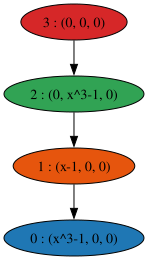

In [22]:
# Adaptive: the chain M3 -> M2 -> M1 -> M0.
CMGDB.PlotMorseGraph(morse_graph)


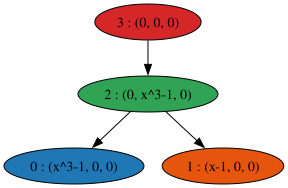

In [23]:
# Verified at depth 20: a fork out of M2, not the chain with one arrow hidden.
CMGDB.PlotMorseGraph(verified_view)


The refined diagram is not the adaptive one with an arrow erased.  In the
adaptive reduction $M_2 \to M_0$ is implied by the two-step path through $M_1$
and so suppressed; once $M_1 \rightsquigarrow M_0$ leaves the *relation* and the
reduction is recomputed, it becomes a covering edge.  The shape changes from a
chain to a fork out of $M_2$.  Below, the verified relation is drawn as
`PlotMorseGraph` renders it, with the removed candidate dashed in red.


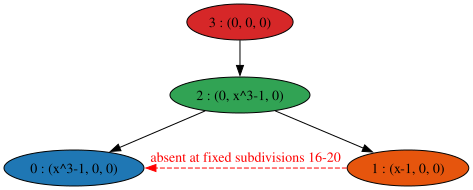

In [24]:
def with_removed_edge(view, removed_edge, label):
    """Overlay a dashed red arrow on the rendered verified Morse graph."""
    body = CMGDB.PlotMorseGraph(view).source.rstrip()
    assert body.endswith("}"), "unexpected graphviz source layout"
    highlight = (
        f'{removed_edge[0]} -> {removed_edge[1]} '
        f'[style=dashed, color=red, fontcolor=red, constraint=false, '
        f'label="{label}"];\n'
    )
    return graphviz.Source(body[:-1] + highlight + "}\n")


with_removed_edge(
    verified_view,
    CANDIDATE,
    f"absent at fixed subdivisions "
    f"{PHASE_SUBDIVISIONS[0]}-{PHASE_SUBDIVISIONS[-1]}",
)


## Interpretation

**Shown.**  The adaptive graph records $M_1 \rightsquigarrow M_0$, inherited from
a coarser level of the hierarchy.  Exhaustive closures at depths $16, \dots, 20$
all return `NOT_REACHABLE`, every closure exhausted and error-free, including at
the decomposition's own resolution.  The counts show why: the closure of $M_1$ is
exactly $M_1$, so it reaches no Morse set other than itself.  Raising
`SUBDIV_INIT` reproduces the same Morse sets and indices without the edge.

**The verdicts.**  `REACHABLE` means a combinatorial path exists in that fixed
outer approximation, which may be a discretisation artifact.  `NOT_REACHABLE`
means the closure was exhausted without meeting the target — a statement about
one combinatorial system at one depth.

**Not established.**

- *Nonreachability for the true dynamics.*  An orbit staying inside the truncated
  phase space would force a combinatorial path in a valid outer approximation, so
  `NOT_REACHABLE` does exclude such an orbit between the cells covering these
  Morse sets.  But those cells only outer-approximate the invariant sets, and the
  domain is not forward invariant, so escaping orbits go untracked.  This is
  evidence about the discretised system, not a theorem about the continuous one.
- *A new Morse decomposition.*  Nothing was recomputed, split, merged, or
  re-indexed; no Conley index was recomputed.
- *Absence of undiscovered recurrent components.*  Cycles among cells outside the
  supplied Morse sets are traversed, not identified.
- *Monotonicity in subdivision.*  Agreement across five depths is an observation
  about this example, not a limit statement — which is why the study reports
  `UNSTABLE` rather than trusting the finest depth.

**Versus spurious Morse sets.**  Those are extra *vertices*, usually with trivial
Conley index, cured by a finer subdivision.  This defect sits in an *edge* whose
endpoints are genuine and nontrivially indexed, $(x-1, 0, 0)$ and
$(x^3-1, 0, 0)$ — but the control run shows the same origin and the same cure, so
it is not a different kind of problem.  ($M_1$ carrying an attractor-type index
while not being minimal is itself the standard signal that `SUBDIV_INIT` was too
coarse.)  What the verifier adds is a certificate on the existing decomposition
without recomputing it.  It never questions a vertex.
